In [3]:
from langgraph.graph import StateGraph, START , END
from typing import TypedDict

In [69]:
# define State
class Batsmen(TypedDict):
    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    balls_per_boundary: float
    boundary_percent: float
    summary: str


In [ ]:
def calculate_sr(state: Batsmen):
    sr = (state['runs']/state['balls'])*100
    state['sr'] = sr
     # instead of sending entire state use partial state (dict) for || workflow
    return {'sr':sr}

In [ ]:
def calculate_balls_per_boundary(state: Batsmen):
    balls_per_boundary = state['balls']/state['fours']+state['sixes']
    state['balls_per_boundary']= balls_per_boundary
    # instead of sending entire state use partial state (dict) for || workflow
    return {'balls_per_boundary':balls_per_boundary}  

In [92]:
def calculate_boundary_percent(state: Batsmen):
    boundary_percent =  (((state['fours'] * 4 + state['sixes'] * 6))/state['runs'])*100
    state['boundary_percent'] = boundary_percent
    # instead of sending entire state use partial state for || workflow
    return {'boundary_percent':boundary_percent}

In [104]:

def summary(state: Batsmen):
    summary = f"""
    Strike Rate - {state['sr']}\n
    Balls per boundary - {state['balls_per_boundary']}\n 
    Boundary percent - {state['boundary_percent']}
    """

    return {'summary':summary}

In [105]:
graph = StateGraph(Batsmen)

# add nodes
graph.add_node('calculate_sr',calculate_sr)
graph.add_node('calculate_balls_per_boundary',calculate_balls_per_boundary)
graph.add_node('calculate_boundary_percent', calculate_boundary_percent)
graph.add_node('summary',summary)

In [106]:
# add edges || workflow
graph.add_edge(START, 'calculate_sr')
graph.add_edge(START,'calculate_balls_per_boundary')
graph.add_edge(START,'calculate_boundary_percent')


graph.add_edge('calculate_sr','summary')
graph.add_edge('calculate_balls_per_boundary','summary')
graph.add_edge('calculate_boundary_percent','summary')

graph.add_edge('summary', END)

workflow = graph.compile()

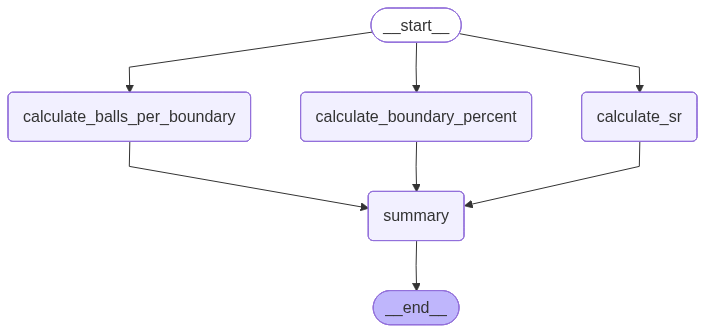

In [107]:
# To print the graph
workflow

In [108]:
initial_state = {
    'runs':100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'balls_per_boundary': 12.333333333333334,
 'boundary_percent': 48.0,
 'summary': '\n    Strike Rate - 200.0\n\n    Balls per boundary - 12.333333333333334\n \n    Boundary percent - 48.0\n    '}